## Challenger Model 1: Feature Level Ensemble

### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# PyTorch and PyTorch Geometric
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATConv
from torch.optim import Adam

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, confusion_matrix
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc

### Performing Log Regression to Feature Select 

In [3]:
# Load dataset
dataset = pd.read_csv('../data/processed/processed_dataset.csv')

# drop irrelevant columns
df_log = dataset.drop(columns=['imei_list', 'phone_no_m']) 
# drop
df_log.drop(columns=["voc_hour_mode",'voc_day_mode','sms_hour_mode','sms_day_mode', 'voc_dayname_mode_count', 'sms_dayname_mode_count', 'flow_sum', 'call_county_unique', 'voc_hour_mode_count', 'sms_day_mode_count'], inplace=True)

# Fill NaN values with 0 
df_log = df_log.fillna(0)

X = df_log.drop(columns=["label"]) 
y = df_log["label"]

# 🔹 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4211, stratify=y)

# 🔹 Standardize Features (Logistic Regression is sensitive to feature scaling)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# # 🔹 Train Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

feature_names = X.columns  # Make sure X is a DataFrame

# Convert X_train and X_test into DataFrames with column names
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)


# Get model coefficients
coef = model.coef_[0]

# Create coefficient DataFrame
coeff_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef
})

# Filter by abs(coef) > 0.25, drop columns that we think will create unnecessary noise
coeff_df['AbsCoefficient'] = np.abs(coeff_df['Coefficient'])
important_features_df = coeff_df[coeff_df['AbsCoefficient'] > 0.25]

# Get list of selected features
selected_features = important_features_df['Feature'].tolist()
columns_to_keep = selected_features

# drop irrelevant columns
df = dataset.drop(columns=['imei_list']) 
df= df.fillna(0)
columns_to_keep += ["phone_no_m","label"]
df = df[columns_to_keep]

#Check the result
print(df['label'].value_counts())
print(df.shape)



label
0    4144
1    1962
Name: count, dtype: int64
(6106, 28)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Creation of Cosine Similarity Matrix 

In [4]:
# Separate the labels and features
labels = df[['phone_no_m', 'label']]  # Extract label columns
features = df.drop(columns=['label'])  # Drop the label column to keep only the features


# Scale the features (exclude 'phone_no_m' from scaling)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features.drop(columns=['phone_no_m']))  # Scale the features

# Store the scaled features and labels
feature_dict = pd.DataFrame(scaled_features, index=features["phone_no_m"]).to_dict(orient="index")  # Store features as a dictionary
label_dict = labels.set_index("phone_no_m").to_dict(orient="index")  # Store labels as a dictionary

# Compute cosine similarity on the scaled features (instead of PCA features)
similarity_matrix = cosine_similarity(scaled_features)  # Cosine similarity directly on scaled features
similarity_df = pd.DataFrame(similarity_matrix, index=df["phone_no_m"], columns=df["phone_no_m"])  # Create a similarity DataFrame

print("similarity_df shape:", similarity_df.shape)

similarity_df shape: (6106, 6106)


### Constructing Our K-Nearest neighbour Graph

In [5]:
# Create Graph
G = nx.Graph()

for idx, row in df.iterrows():
    G.add_node(row['phone_no_m'], label=row['label'])


k_nearest_neighbours = 15 ## during testing, this value has been adjusted from 10,15,20,50

for i, phone1 in enumerate(df["phone_no_m"]):
    
    similarities = [
        (j, similarity_matrix[i, j])
        for j in range(len(df["phone_no_m"])) if i != j
    ]

    positive = sorted([p for p in similarities], key=lambda x: x[1], reverse=True)

    # Select neighbors based strictly on k-nearest neighbours
    selected = []
    selected += positive[:k_nearest_neighbours]

    # Step 6: Add edges to graph (skip padding!)
    for neighbor_idx, sim in selected:
        neighbor = df["phone_no_m"].iloc[neighbor_idx]
        G.add_edge(phone1, neighbor, weight=sim)


# Map node IDs to indices
node_mapping = {node: idx for idx, node in enumerate(G.nodes())}

# Convert edges into PyTorch Geometric format
edge_index = torch.tensor([(node_mapping[u], node_mapping[v]) for u, v in G.edges()], dtype=torch.long).t()

# Convert edge weights
edge_attr = torch.tensor([G[u][v]['weight'] for u, v in G.edges()], dtype=torch.float)

print("Graph Construction Done! Number of Nodes:", len(G.nodes()), "Number of Edges:", len(G.edges()))



Graph Construction Done! Number of Nodes: 6106 Number of Edges: 65570


### Graph Data Preparation with Stratified Split

In [6]:
# Create the 'x' tensor from 'feature_dict'
# Assuming feature_dict contains feature vectors (e.g., list or array) for each node
x = np.array([list(features.values()) for features in feature_dict.values()])
x = torch.tensor(x, dtype=torch.float)

# Create the 'y' tensor from 'label_dict'
# Ensure label_dict stores the correct value
# Example: if label_dict[phone_no] returns a dictionary with the key 'label' holding the integer label:
y = torch.tensor([label_dict[phone_no]['label'] for phone_no in feature_dict.keys()], dtype=torch.long)

# Create the PyTorch Geometric Data object
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
print(data)

# Set seed for reproducibility
torch.manual_seed(4263)

def prepare_data_stratified(data, train_ratio=0.8):
    num_nodes = data.num_nodes
    labels = data.y.numpy()
    
    # Stratified split into train and test
    idx = np.arange(num_nodes)
    train_idx, test_idx = train_test_split(
        idx, train_size=train_ratio, stratify=labels, random_state=40
    )
    
    # Create masks
    data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)
    
    data.train_mask[train_idx] = True
    data.test_mask[test_idx] = True
    
    return data

# Apply the stratified train-test split (80% train, 20% test)
data = prepare_data_stratified(data, train_ratio=0.8)

# Check mask sizes
print(f"Number of nodes in data.x: {data.x.shape[0]}")
print(f"Train mask size: {data.train_mask.sum().item()}")
print(f"Test mask size: {data.test_mask.sum().item()}")


Data(x=[6106, 26], edge_index=[2, 65570], edge_attr=[65570], y=[6106])
Number of nodes in data.x: 6106
Train mask size: 4884
Test mask size: 1222


### Model Definitions – GCN, GAT, GraphSAGE

In [ ]:
class GCNModel(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCNModel, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

    def encode(self, x, edge_index):
        return self.forward(x, edge_index)  # Alias for extracting embeddings

class GATModel(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GATModel, self).__init__()
        self.conv1 = GATConv(input_dim, hidden_dim, heads=8)
        self.conv2 = GATConv(hidden_dim * 8, output_dim, heads=1)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x
    
    def encode(self, x, edge_index):
        return self.forward(x, edge_index)  # Alias for extracting embeddings


class GraphSAGEModel(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GraphSAGEModel, self).__init__()
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

    def encode(self, x, edge_index):
        return self.forward(x, edge_index)  # for extracting embeddings

### Training GCN, GAT, GraphSAGE concurrently

In [8]:
def train(model, data, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

input_dim = data.x.shape[1] 
hidden_dim = 64  
output_dim = len(torch.unique(data.y))

# Initialize models
model_gcn = GCNModel(input_dim, hidden_dim, output_dim)
model_gat = GATModel(input_dim, hidden_dim, output_dim)
model_sage = GraphSAGEModel(input_dim, hidden_dim, output_dim)

# Define optimizers
optimizer_gcn = Adam(model_gcn.parameters(), lr=0.01)
optimizer_gat = Adam(model_gat.parameters(), lr=0.01)
optimizer_sage = Adam(model_sage.parameters(), lr=0.005)

# Compute class counts (assuming binary classification: 0 and 1)
num_class_0 = (data.y[data.train_mask] == 0).sum().item()
num_class_1 = (data.y[data.train_mask] == 1).sum().item()
total = num_class_0 + num_class_1

# Calculate inverse frequency weights to account for class imbalance issue
weight_0 = total / (2 * num_class_0)
weight_1 = total / (2 * num_class_1)

# Define the weighted loss function
class_weights = torch.tensor([weight_0, weight_1], dtype=torch.float, device=data.y.device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)


# Training loop
for epoch in range(500):
    loss_gcn = train(model_gcn, data, optimizer_gcn, criterion)
    loss_gat = train(model_gat, data, optimizer_gat, criterion)
    loss_sage = train(model_sage, data, optimizer_sage, criterion)
    
    if epoch % 100 == 0:
        print(f'Epoch {epoch}:')
        print(f'  GCN Loss: {loss_gcn:.4f}')
        print(f'  GAT Loss: {loss_gat:.4f}')
        print(f'  SAGE Loss: {loss_sage:.4f}')


Epoch 0:
  GCN Loss: 0.7289
  GAT Loss: 0.7715
  SAGE Loss: 0.7984
Epoch 100:
  GCN Loss: 0.2888
  GAT Loss: 0.2612
  SAGE Loss: 0.2393
Epoch 200:
  GCN Loss: 0.2797
  GAT Loss: 0.2442
  SAGE Loss: 0.2149
Epoch 300:
  GCN Loss: 0.2741
  GAT Loss: 0.2287
  SAGE Loss: 0.2001
Epoch 400:
  GCN Loss: 0.2680
  GAT Loss: 0.2209
  SAGE Loss: 0.1897


### Extracting Node Embeddings

In [9]:
def get_node_embeddings(model, data):
    model.eval()
    with torch.no_grad():
        embeddings = model.encode(data.x, data.edge_index)
    return embeddings

test = data.test_mask
gcn_emb = get_node_embeddings(model_gcn, data )  # (num_nodes, emb_dim)
sage_emb = get_node_embeddings(model_sage, data)  # (num_nodes, emb_dim)
gat_emb = get_node_embeddings(model_gat, data)  # (num_nodes, emb_dim)


### Ensemble 1: Calculating GAT + Random Forest Accuracy

In [10]:
## Use only GAT embeddings
fused_embeddings_gat = gat_emb[test]  # (num_nodes, emb_dim)

# Convert PyTorch tensor to NumPy for scikit-learn
X = fused_embeddings_gat.cpu().numpy()
y = data.y[test].cpu().numpy()

results = []
conf_matrices = []

for seed in range(100):
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    # Train classifier
    clf = RandomForestClassifier(n_estimators=100, random_state=seed)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Save confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    conf_matrices.append(cm)

# Average confusion matrix
avg_conf_matrix = np.mean(conf_matrices, axis=0).round().astype(int)

print("\nAverage Confusion Matrix (rounded over 100 runs):")
print(pd.DataFrame(avg_conf_matrix, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))

y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate AUC-ROC score
auc_roc = roc_auc_score(y_test, y_pred_proba)

# Extract values from the confusion matrix
tn, fp, fn, tp = avg_conf_matrix.ravel()

# Calculate metrics based on the average confusion matrix
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_1 = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_1 = 2 * precision_1 * recall_1 / (precision_1 + recall_1) if (precision_1 + recall_1) > 0 else 0

precision_0 = tn / (tn + fp) if (tn + fp) > 0 else 0
recall_0 = tn / (tn + fn) if (tn + fn) > 0 else 0
f1_0 = 2 * precision_0 * recall_0 / (precision_0 + recall_0) if (precision_0 + recall_0) > 0 else 0

# Print metrics
print("\nMetrics computed from the average confusion matrix:")
print(f"{'amt_of_neighbour_nodes':25} {k_nearest_neighbours:.6f}")
print(f"{'accuracy':25} {accuracy:.6f}")
print(f"{'precision_1':25} {precision_1:.6f}")
print(f"{'recall_1':25} {recall_1:.6f}")
print(f"{'f1_score_1':25} {f1_1:.6f}")
print(f"{'precision_0':25} {precision_0:.6f}")
print(f"{'recall_0':25} {recall_0:.6f}")
print(f"{'f1_score_0':25} {f1_0:.6f}")
print(f"{'auc_roc_score':25} {auc_roc:.6f}")


Average Confusion Matrix (rounded over 100 runs):
          Pred 0  Pred 1
Actual 0     158       8
Actual 1      17      62

Metrics computed from the average confusion matrix:
amt_of_neighbour_nodes    15.000000
accuracy                  0.897959
precision_1               0.885714
recall_1                  0.784810
f1_score_1                0.832215
precision_0               0.951807
recall_0                  0.902857
f1_score_0                0.926686
auc_roc_score             0.932972


### Ensemble 2: Calculating GCN + Random Forest Accuracy

In [11]:
# # Use only GCN embeddings
fused_embeddings_gcn = gcn_emb[test]  # (num_nodes, emb_dim)

# Convert PyTorch tensor to NumPy for scikit-learn
X = fused_embeddings_gcn.cpu().numpy()
y = data.y[test].cpu().numpy()
##################################################################################################

results = []
conf_matrices = []

for seed in range(100):
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    # Train classifier
    clf = RandomForestClassifier(n_estimators=100, random_state=seed)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Save confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    conf_matrices.append(cm)

    

# Average confusion matrix
avg_conf_matrix = np.mean(conf_matrices, axis=0).round().astype(int)

print("\nAverage Confusion Matrix (rounded over 100 runs):")
print(pd.DataFrame(avg_conf_matrix, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))

y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate AUC-ROC score
auc_roc = roc_auc_score(y_test, y_pred_proba)

# Extract values from the confusion matrix
tn, fp, fn, tp = avg_conf_matrix.ravel()

# Calculate metrics based on the average confusion matrix
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_1 = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_1 = 2 * precision_1 * recall_1 / (precision_1 + recall_1) if (precision_1 + recall_1) > 0 else 0

precision_0 = tn / (tn + fp) if (tn + fp) > 0 else 0
recall_0 = tn / (tn + fn) if (tn + fn) > 0 else 0
f1_0 = 2 * precision_0 * recall_0 / (precision_0 + recall_0) if (precision_0 + recall_0) > 0 else 0

# Print metrics
print("\nMetrics computed from the average confusion matrix:")
print(f"{'amt_of_neighbour_nodes':25} {k_nearest_neighbours:.6f}")
print(f"{'accuracy':25} {accuracy:.6f}")
print(f"{'precision_1':25} {precision_1:.6f}")
print(f"{'recall_1':25} {recall_1:.6f}")
print(f"{'f1_score_1':25} {f1_1:.6f}")
print(f"{'precision_0':25} {precision_0:.6f}")
print(f"{'recall_0':25} {recall_0:.6f}")
print(f"{'f1_score_0':25} {f1_0:.6f}")
print(f"{'auc_roc_score':25} {auc_roc:.6f}")


Average Confusion Matrix (rounded over 100 runs):
          Pred 0  Pred 1
Actual 0     157       9
Actual 1      17      62

Metrics computed from the average confusion matrix:
amt_of_neighbour_nodes    15.000000
accuracy                  0.893878
precision_1               0.873239
recall_1                  0.784810
f1_score_1                0.826667
precision_0               0.945783
recall_0                  0.902299
f1_score_0                0.923529
auc_roc_score             0.937776


### Ensemble 3: Calculating GraphSAGE + Random Forest Accuracy

In [12]:
# # Use only SAGE embeddings
fused_embeddings_sage = sage_emb[test]  # (num_nodes, emb_dim)

# Convert PyTorch tensor to NumPy for scikit-learn
X = fused_embeddings_sage.cpu().numpy()
y = data.y[test].cpu().numpy()
##################################################################################################
    
results = []
conf_matrices = []

for seed in range(100):
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    # Train classifier
    clf = RandomForestClassifier(n_estimators=100, random_state=seed)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Save confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    conf_matrices.append(cm)

    

# Average confusion matrix
avg_conf_matrix = np.mean(conf_matrices, axis=0).round().astype(int)

print("\nAverage Confusion Matrix (rounded over 100 runs):")
print(pd.DataFrame(avg_conf_matrix, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))

y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate AUC-ROC score
auc_roc = roc_auc_score(y_test, y_pred_proba)

# Extract values from the confusion matrix
tn, fp, fn, tp = avg_conf_matrix.ravel()

# Calculate metrics based on the average confusion matrix
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_1 = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_1 = 2 * precision_1 * recall_1 / (precision_1 + recall_1) if (precision_1 + recall_1) > 0 else 0

precision_0 = tn / (tn + fp) if (tn + fp) > 0 else 0
recall_0 = tn / (tn + fn) if (tn + fn) > 0 else 0
f1_0 = 2 * precision_0 * recall_0 / (precision_0 + recall_0) if (precision_0 + recall_0) > 0 else 0

# Print metrics
print("\nMetrics computed from the average confusion matrix:")
print(f"{'amt_of_neighbour_nodes':25} {k_nearest_neighbours:.6f}")
print(f"{'accuracy':25} {accuracy:.6f}")
print(f"{'precision_1':25} {precision_1:.6f}")
print(f"{'recall_1':25} {recall_1:.6f}")
print(f"{'f1_score_1':25} {f1_1:.6f}")
print(f"{'precision_0':25} {precision_0:.6f}")
print(f"{'recall_0':25} {recall_0:.6f}")
print(f"{'f1_score_0':25} {f1_0:.6f}")
print(f"{'auc_roc_score':25} {auc_roc:.6f}")


Average Confusion Matrix (rounded over 100 runs):
          Pred 0  Pred 1
Actual 0     160       6
Actual 1      12      67

Metrics computed from the average confusion matrix:
amt_of_neighbour_nodes    15.000000
accuracy                  0.926531
precision_1               0.917808
recall_1                  0.848101
f1_score_1                0.881579
precision_0               0.963855
recall_0                  0.930233
f1_score_0                0.946746
auc_roc_score             0.929541


### Ensemble 4: Calculating (GAT + GCN + GraphSAGE) + Random Forest Accuracy

In [13]:
# Concatenate along the feature dimension
fused_embeddings_concat = torch.cat([gcn_emb[test], sage_emb[test], gat_emb[test]], dim=1)  # (num_nodes, 3 * emb_dim)


# Convert PyTorch tensors to NumPy for scikit-learn
X = fused_embeddings_concat.cpu().numpy()  # or fused_embeddings_avg.cpu().numpy() or fused_embeddings_concat.cpu().numpy()
y = data.y[test].cpu().numpy()
####################################################################################################

results = []
conf_matrices = []

for seed in range(100):
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    # Train classifier
    clf = RandomForestClassifier(n_estimators=100, random_state=seed)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Save confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    conf_matrices.append(cm)


# Average confusion matrix
avg_conf_matrix = np.mean(conf_matrices, axis=0).round().astype(int)

print("\nAverage Confusion Matrix (rounded over 100 runs):")
print(pd.DataFrame(avg_conf_matrix, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))

y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate AUC-ROC score
auc_roc = roc_auc_score(y_test, y_pred_proba)

# Extract values from the confusion matrix
tn, fp, fn, tp = avg_conf_matrix.ravel()

# Calculate metrics based on the average confusion matrix
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_1 = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_1 = 2 * precision_1 * recall_1 / (precision_1 + recall_1) if (precision_1 + recall_1) > 0 else 0

precision_0 = tn / (tn + fp) if (tn + fp) > 0 else 0
recall_0 = tn / (tn + fn) if (tn + fn) > 0 else 0
f1_0 = 2 * precision_0 * recall_0 / (precision_0 + recall_0) if (precision_0 + recall_0) > 0 else 0

# Print metrics
print("\nMetrics computed from the average confusion matrix:")
print(f"{'amt_of_neighbour_nodes':25} {k_nearest_neighbours:.6f}")
print(f"{'accuracy':25} {accuracy:.6f}")
print(f"{'precision_1':25} {precision_1:.6f}")
print(f"{'recall_1':25} {recall_1:.6f}")
print(f"{'f1_score_1':25} {f1_1:.6f}")
print(f"{'precision_0':25} {precision_0:.6f}")
print(f"{'recall_0':25} {recall_0:.6f}")
print(f"{'f1_score_0':25} {f1_0:.6f}")
print(f"{'auc_roc_score':25} {auc_roc:.6f}")



Average Confusion Matrix (rounded over 100 runs):
          Pred 0  Pred 1
Actual 0     162       4
Actual 1      12      67

Metrics computed from the average confusion matrix:
amt_of_neighbour_nodes    15.000000
accuracy                  0.934694
precision_1               0.943662
recall_1                  0.848101
f1_score_1                0.893333
precision_0               0.975904
recall_0                  0.931034
f1_score_0                0.952941
auc_roc_score             0.942009


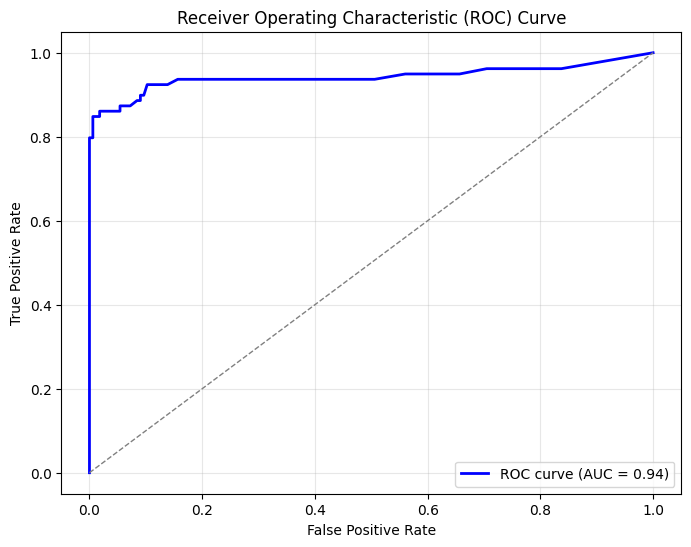

In [ ]:
# Compute the ROC curve and AUC score
fpr, tpr, _ = roc_curve(y_test, clf.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()